# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
...
print("Tỷ lệ missing của tất cả các cột (%):")
print(df.isnull().mean() * 100)
print("-" * 40)
# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town','alone']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)
df = df.drop(columns=[col for col in leaky if col in df.columns])
# print("Các cột còn lại:", list(df.columns))
print("Các cột còn lại:", list(df.columns))

Tỷ lệ missing của tất cả các cột (%):
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64
----------------------------------------
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*(viết tại đây...)*

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
...
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
print("Biến mục tiêu (target): 'survived'\n")

print("--- INFO ---")
df.info()

print("\n--- DESCRIBE (NUMERIC) ---")
print(df.describe())

print("\n--- DESCRIBE (CATEGORICAL) ---")
print(df.describe(include=['object', 'category']))

Số dòng: 891, Số cột: 8
Biến mục tiêu (target): 'survived'

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

--- DESCRIBE (NUMERIC) ---
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000 

**Trả lời 2 (biến số vs biến phân loại):**

*(viết tại đây...)*

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
...
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_df = pd.DataFrame({'Số lượng thiếu': missing_count, 'Phần trăm thiếu (%)': missing_pct})

print("Các cột có giá trị thiếu:")
print(missing_df[missing_df['Số lượng thiếu'] > 0])

Các cột có giá trị thiếu:
          Số lượng thiếu  Phần trăm thiếu (%)
age                  177            19.865320
embarked               2             0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| ... | ... | ... | ... |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    # trả về số lượng outlier theo IQR
  q1 = s.quantile(0.25)
  q3 = s.quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  return ((s < lower_bound) | (s > upper_bound)).sum()
def dem_outlier_zscore(s, nguong=3.0):
    # trả về số lượng outlier theo Z-score
  z_scores = np.abs(stats.zscore(s.dropna()))
  return (z_scores > nguong).sum()
# for col in ["age", "fare"]:
#     ...
for col in ['age', 'fare']:
  print(f"Cột '{col}':")
  print(f"  - Số outlier theo IQR: {dem_outlier_iqr(df[col])}")
  print(f"  - Số outlier theo Z-score: {dem_outlier_zscore(df[col])}")

Cột 'age':
  - Số outlier theo IQR: 11
  - Số outlier theo Z-score: 2
Cột 'fare':
  - Số outlier theo IQR: 116
  - Số outlier theo Z-score: 20


**Trả lời 4 (quyết định với outlier của `fare`):**

*(viết tại đây...)*

Giữ lại các giá trị outlier của cột fare. Lý do là vì mức giá vé cao bất thường (lên tới hơn $500$) không phải lỗi nhập liệu, mà nó phản ánh thực tế lịch sử về các hạng vé siêu sang dành cho giới thượng lưu (First Class) trên tàu Titanic. Đặc trưng này chứa thông tin cực kỳ quan trọng cho bài toán, vì những người giàu có mua vé đắt thường có vị trí phòng an toàn hơn và được ưu tiên xuống thuyền cứu hộ trước, dẫn đến tỷ lệ sống sót cao hơn rõ rệt.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

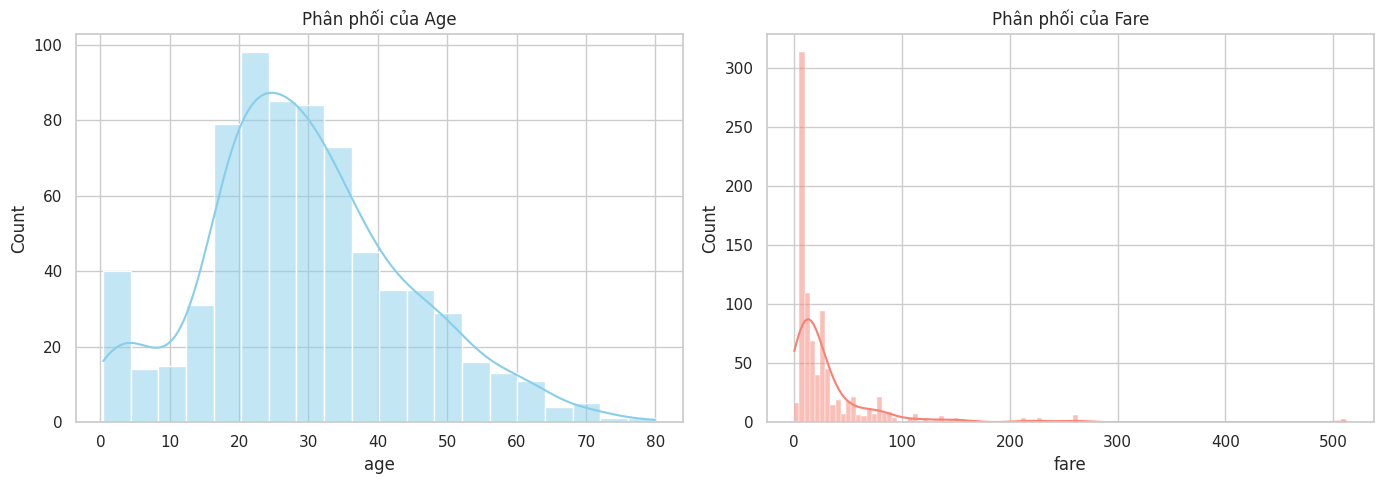

In [7]:
# TODO 5a: Histogram age & fare
...
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của Age')

sns.histplot(df['fare'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối của Fare')
plt.tight_layout()
plt.show()

/tmp/ipykernel_16154/216301836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='survived', y='fare', palette='Set2')


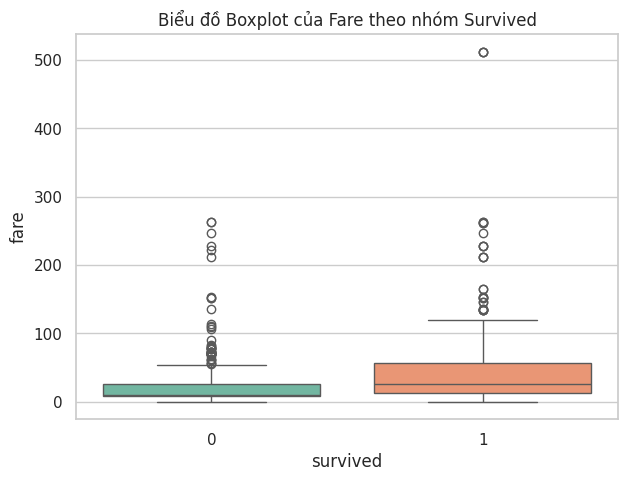

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
...
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='survived', y='fare', palette='Set2')
plt.title('Biểu đồ Boxplot của Fare theo nhóm Survived')
plt.show()

/tmp/ipykernel_16154/2678671080.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', ax=axes[0], errorbar=None, palette='pastel')
/tmp/ipykernel_16154/2678671080.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], errorbar=None, palette='muted')


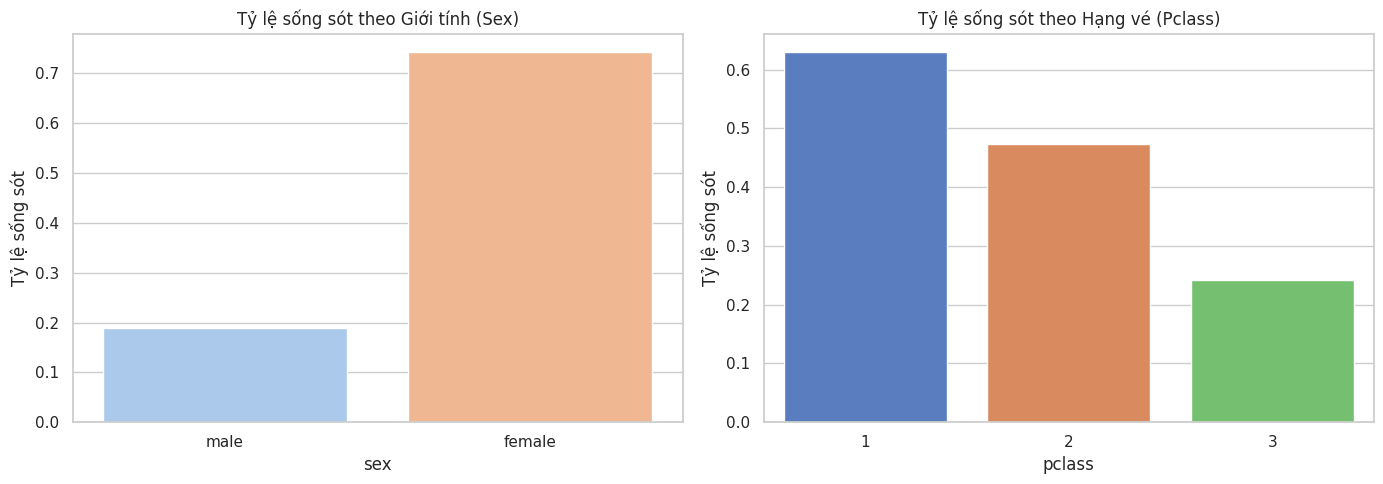

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
...
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='sex', y='survived', ax=axes[0], errorbar=None, palette='pastel')
axes[0].set_title('Tỷ lệ sống sót theo Giới tính (Sex)')
axes[0].set_ylabel('Tỷ lệ sống sót')

sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], errorbar=None, palette='muted')
axes[1].set_title('Tỷ lệ sống sót theo Hạng vé (Pclass)')
axes[1].set_ylabel('Tỷ lệ sống sót')
plt.tight_layout()
plt.show()

In [10]:
# TODO 5d: Heatmap correlation
...

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram:  Biến age có dạng phân phối gần chuẩn nhưng hơi lệch phải, tập trung đông nhất ở độ tuổi thanh niên từ 20-40 tuổi. Biến fare có phân phối lệch phải cực kỳ nghiêm trọng, hầu hết hành khách mua vé giá rẻ (dưới $50$), chỉ có một số rất ít mua vé giá cực kỳ cao.
- Boxplot: Nhóm sống sót có mức giá vé trung vị cao hơn hẳn nhóm thiệt mạng. Ngoài ra, phần lớn các outlier có giá vé siêu đắt đều tập trung ở nhóm sống sót.
- Bar survival: Tỷ lệ sống sót có sự phân hóa cực kỳ sâu sắc. Nữ giới có tỷ lệ sống sót vượt trội (>70%) so với nam giới (<20%). Xét theo hạng ghế, hành khách hạng 1 (pclass=1) có tỷ lệ sống sót cao nhất, tiếp theo là hạng 2 và thấp nhất là hạng 3.
- Heatmap: Cặp biến có tương quan mạnh nhất là pclass và fare ($-0.55$), đây là mối tương quan nghịch hợp lý (hạng vé số 1 là hạng sang trọng nhất nên giá tiền tương ứng sẽ lớn nhất). Biến survived có tương quan thuận rõ nhất với fare ($0.26$) và tương quan nghịch rõ nhất với pclass ($-0.34$).

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=['survived'])
y = df['survived']

# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
# X_train, X_val, y_train, y_val = train_test_split(...)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=(0.15 / 0.85), random_state=42, stratify=y_tmp)
# print("Train/Val/Test:", ...)
print(f"Shape của tập Train: {X_train.shape}")
print(f"Shape của tập Val:   {X_val.shape}")
print(f"Shape của tập Test:  {X_test.shape}\n")
# in tỷ lệ survived từng tập
print(f"Tỷ lệ sống sót trong tập Train: {y_train.mean():.2%}")
print(f"Tỷ lệ sống sót trong tập Val:   {y_val.mean():.2%}")
print(f"Tỷ lệ sống sót trong tập Test:  {y_test.mean():.2%}")

Shape của tập Train: (623, 7)
Shape của tập Val:   (134, 7)
Shape của tập Test:  (134, 7)

Tỷ lệ sống sót trong tập Train: 38.36%
Tỷ lệ sống sót trong tập Val:   38.81%
Tỷ lệ sống sót trong tập Test:  38.06%


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    # ("imputer", ...),
    ("imputer", SimpleImputer(strategy="median")),
    # ("scaler",  ...),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    # ("imputer", ...),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # ("onehot",  ...),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),

])

preprocess = ColumnTransformer([
    # ("num", pipe_so,  num_cols),
    ("num", pipe_so,  num_cols),
    # ("cat", pipe_cat, cat_cols),
    ("cat", pipe_cat, cat_cols),
    # ("ord", "passthrough", ord_cols),
    ("ord", "passthrough", ord_cols),

])

# preprocess.fit(X_train)               # fit CHỈ trên train
preprocess.fit(X_train)
# X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
X_train_t = preprocess.transform(X_train)
X_val_t   = preprocess.transform(X_val)
X_test_t  = preprocess.transform(X_test)
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))
print("Kích thước X_train sau biến đổi:", X_train_t.shape)
print("Danh sách tên cột mới:")
print(list(preprocess.get_feature_names_out()))

Kích thước X_train sau biến đổi: (623, 10)
Danh sách tên cột mới:
['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

*(viết tại đây...)*

Việc fit các công cụ tiền xử lý (như tính toán trung vị để điền giá trị khuyết, tính toán phân vị để scale dữ liệu) chỉ trên tập huấn luyện (train) nhằm đảm bảo mô hình không biết trước bất kỳ thông tin thống kê nào của tập validation và test. Nếu ta dùng toàn bộ dữ liệu để fit, thông tin từ tương lai (tập kiểm thử) sẽ bị rò rỉ vào quá trình chuẩn hóa dữ liệu, khiến kết quả đánh giá mô hình trên tập validation/test bị "đẹp ảo" (overoptimistic) nhưng khi chạy thực tế trên dữ liệu hoàn toàn mới sẽ cho kết quả rất tệ.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
...
print(df['survived'].value_counts(normalize=True))

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến mục tiêu survived có xảy ra hiện tượng mất cân bằng dữ liệu ở mức độ nhẹ đến vừa phải (khoảng ~61.62% thiệt mạng và ~38.38% sống sót).
2. Nếu chỉ nhìn vào Accuracy, chúng ta rất dễ bị đánh lừa khi dữ liệu mất cân bằng nghiêm trọng. Ví dụ, nếu một bộ dữ liệu có 95% hành khách thiệt mạng, một mô hình "ngây thơ" chỉ cần dự đoán tất cả mọi người đều chết thì đã đạt tới 95% Accuracy, nhưng thực chất mô hình đó hoàn toàn vô dụng vì không tìm ra được bất kỳ ai sống sót.
3. Với bài toán Titanic, chúng ta nên ưu tiên chỉ số F1-Score. Vì F1-Score là trung bình điều hòa giữa Precision và Recall, giúp đánh giá một cách cân bằng và chính xác hiệu năng của mô hình trên cả hai nhóm (sống sót và thiệt mạng) mà không bị che mắt bởi lớp đa số chiếm ưu thế.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất: Dựa trên ma trận tương quan và biểu đồ thanh, đặc trưng giới tính (sex) và hạng vé (pclass) thể hiện sự tương quan rõ rệt nhất tới khả năng sống sót. Số liệu cho thấy tỷ lệ sống sót của Nữ giới đạt trên 70% trong khi Nam giới dưới 20%.
2. Cột thiếu nhiều nhất: Cột age thiếu gần 20% dữ liệu và đã được xử lý thành công bằng phương pháp điền khuyết Trung vị (Median) ngay bên trong pipeline huấn luyện để tránh rò rỉ thông tin.
3. Mất cân bằng và ảnh hưởng chọn metric: Biến mục tiêu có sự chênh lệch (61.6% so với 38.4%). Do dữ liệu có sự mất cân bằng này, việc dùng đơn thuần chỉ số Accuracy sẽ không phản ánh đúng năng lực thật của mô hình, do đó chỉ số F1-Score đã được lựa chọn làm thước đo chính.
4. Yêu cầu Scaling và Encoding: Các biến số như fare và age cần được thực hiện kỹ thuật Scaling (sử dụng RobustScaler) do có sự chênh lệch lớn về đơn vị tính toán và chứa nhiều outlier. Các biến như sex và embarked bắt buộc phải áp dụng kỹ thuật Encoding (OneHotEncoder) để chuyển đổi từ dạng chuỗi ký tự sang dạng số nhị phân giúp thuật toán Machine Learning hiểu được.
5. Điều bất ngờ/thú vị: Quy luật ngầm mang tính nhân văn của thảm họa "Phụ nữ và trẻ em được ưu tiên trước" (Women and children first) được thể hiện vô cùng sắc nét qua số liệu thực tế. Ngoài ra, yếu tố địa vị xã hội (thể hiện qua giá vé fare và hạng ghế pclass) đóng một vai trò mang tính quyết định đến cơ hội sống còn của một con người khi đối mặt với thảm họa.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
